# Смирнов Сергей ФПэ-01-22


Определить угол поворота в рабочем колесе $\Delta \beta = \beta_1 - \beta_2$ на среднем радиусе, если подведенная работа $L_{ст}$ = 25 кДж/кг, окружная скорость вращения колеса на среднем радиусе u = 328 м/c. Составляющие скорости на входе $c_{1u}$ = 70 м/с, $c_{1a}$ = 145 м/c. Принять $c_{1a} = c_{2a} = w_{1a} = w_{2a}$. Построить треугольники скоростей и вывести скорости и углы.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
MW = 10**6
to_kelvin = lambda x: x + 273.15
kJ = 10**3

In [3]:
stage_work = 16 * kJ
c_1_a = 145 
c_1_u = 70
u = 328

c_1 = (c_1_a ** 2 + c_1_u ** 2) ** 0.5
alpha_1 = np.rad2deg(np.arccos(c_1_u / c_1))

In [4]:
w_1_u = c_1_u - u
w_1_a = c_1_a

In [5]:
def plot_triangle(
    ax,
    u = None,
    c_a = None,
    c_u = None,
    w_a = None,
    w_u = None,
    **kwargs,
):
    if c_u and c_a:
        ax.plot([0, -c_u], [0, -c_a], label='C_1', color='red', **kwargs)
    if w_u and w_a:
        ax.plot([0, -w_u], [0, -w_a], label='W_1', color='green', **kwargs)
    if (c_u and c_a) or (w_u and w_a):
        if c_u and c_a:
            ax.plot([-c_u, -c_u + u], [-c_a, -c_a], label='u', color='blue', **kwargs)
        else:
            ax.plot([-w_u, -w_u - u], [-w_a, -w_a], label='u', color='blue', **kwargs)
    ax.legend()

In [6]:
w_1 = (w_1_a ** 2 + w_1_u ** 2) ** 0.5
beta_1 = np.rad2deg(np.arccos(w_1_u / w_1))
delta_w_u = stage_work / u
w_2_u = w_1_u + delta_w_u
w_2_a = c_1_a

In [7]:
w_2 = (w_2_a ** 2 + w_2_u**2) ** 0.5
beta_2 = np.rad2deg(np.arccos(w_2_u / w_2))
delta_c_u = delta_w_u
c_2_u = c_1_u + delta_c_u
c_2_a = c_1_a

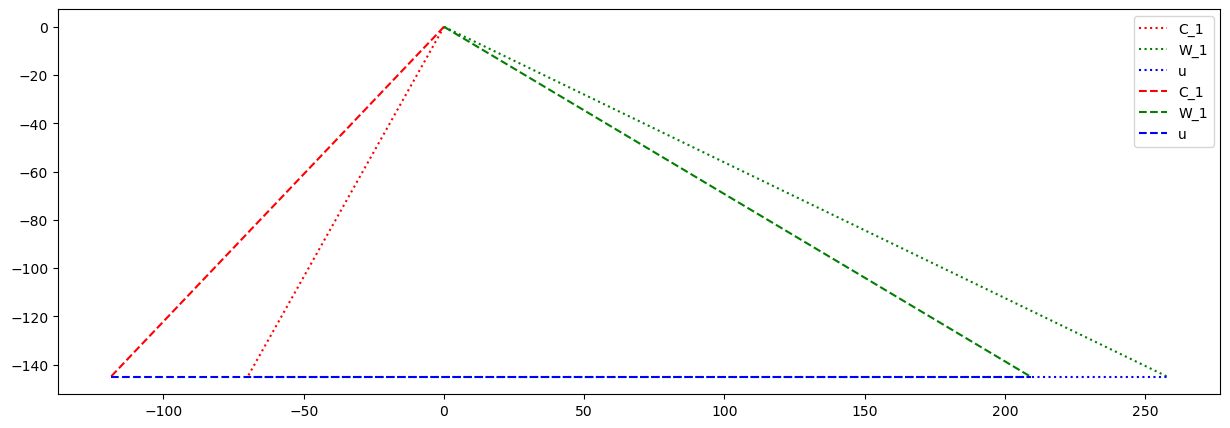

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(15,5))
plot_triangle(ax=ax, u=u, c_u=c_1_u, c_a=c_1_a, w_a=w_1_a, w_u=w_1_u, linestyle="dotted")
plot_triangle(ax=ax, u=u, w_a=w_2_a, w_u=w_2_u, c_a=c_2_a, c_u=c_2_u, linestyle="dashed")

In [9]:
c_2 = (c_2_u ** 2 + c_2_a ** 2) ** 0.5
alpha_2 = np.rad2deg(np.arcsin(c_2_a / c_2))

In [14]:
table = pd.DataFrame({
    "Абсолютная скорость $c$": [c_1, c_2],
    "Абсолютный угол $alpha$": [alpha_1, alpha_2],
    "отсносительная скорость, $w$": [w_1, w_2],
    "относительный угол $beta$": [beta_1, beta_2],
    "треугольник": ["входной", "выходной"],
}).set_index("треугольник")
table

,Абсолютная скорость $c$,Абсолютный угол $alpha$,"отсносительная скорость, $w$",относительный угол $beta$
треугольник,,,,
входной,161.012422,64.230672,295.954388,150.663338
выходной,187.440135,50.676496,254.554128,145.276028
